<a href="https://colab.research.google.com/github/PavaniMaganti/HR-Workforce-Analytics-Employee-Retention/blob/main/HR_Workforce_Analytics_Employee_Retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introduction

HR Workforce Analytics & Employee Retention Analysis

# Objective

The objective of this project is to identify the key factors influencing employee attrition and provide data-driven recommendations to improve employee retention.

In [1]:
import pandas as pd

df = pd.read_csv('/content/HR_Analytics.csv')

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

## 2.Data Quality Assessment

- Dataset contains 1,480 employee records.
- 7 duplicate records were identified and removed.
- 57 missing values were found in YearsWithCurrManager.
- Remaining columns contained no missing values.

**Step 1: Checking Missing Values Properly**

In [2]:
df.isnull().sum().sort_values(ascending=False)

,0
YearsWithCurrManager,57
EmpID,0
AgeGroup,0
Attrition,0
BusinessTravel,0
Age,0
DailyRate,0
Department,0
Education,0
DistanceFromHome,0


**Step 2: Investigate Missing Values**




In [3]:
df[df['YearsWithCurrManager'].isnull()].head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
28,RM024,21,18-25,No,Travel_Rarely,391,Research & Development,15,2,Life Sciences,...,4,80,0,0,6,3,0,0,0,NaN
31,RM363,21,18-25,No,Non-Travel,895,Sales,9,2,Medical,...,3,80,0,3,3,2,3,2,2,NaN
45,RM207,22,18-25,No,Travel_Rarely,1136,Research & Development,5,3,Life Sciences,...,1,80,1,4,2,2,4,2,2,NaN
99,RM139,25,18-25,No,Travel_Rarely,959,Sales,28,3,Life Sciences,...,4,80,0,6,3,3,2,2,2,NaN
100,RM256,25,18-25,No,Travel_Rarely,685,Research & Development,1,3,Life Sciences,...,4,80,2,5,3,3,4,2,1,NaN


**Step 3: Check Duplicates**



In [4]:
df.duplicated().sum()

np.int64(7)

In [5]:
duplicates = df[df.duplicated()]
duplicates

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
1305,RM1469,49,46-55,No,Travel_Frequently,1023,Sales,2,3,Medical,...,4,80,0,17,3,2,9,6,0,8.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0


In [6]:
duplicates.shape

(7, 38)

In [7]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
210,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
327,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
457,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
654,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
952,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0


In [8]:
duplicates[['EmpID','EmployeeNumber']].sort_values('EmpID')

,EmpID,EmployeeNumber
327,RM1461,2054
328,RM1461,2054
1335,RM1462,2055
1336,RM1462,2055
952,RM1463,2056
954,RM1463,2056
457,RM1464,2057
458,RM1464,2057
210,RM1468,2064
211,RM1468,2064


In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(1473, 38)

## Duplicate Record Assessment

7 duplicate employee records were identified.

*   The duplicates shared identical values across all 38 columns, including EmpID and EmployeeNumber, confirming that they represented duplicate entries rather than unique employees.
*   These records were removed to prevent inflation of workforce metrics.

In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
YearsWithCurrManager,57
EmpID,0
AgeGroup,0
Attrition,0
BusinessTravel,0
Age,0
DailyRate,0
Department,0
Education,0
DistanceFromHome,0


# 3. Exploratory Data Analysis

### ## Exploratory Data Analysis

### Attrition Overview
*   The organization has an attrition rate of 16.09%, indicating that approximately one in six employees leaves the company. Employee retention should therefore be considered an important business objective.




### Department Analysis

*   Attrition rates vary across departments, with Sales recording the highest turnover (20.58%) and Research & Development the lowest (13.81%). This suggests retention challenges are not evenly distributed across the organization.

### Job Role Analysis

*   Sales Representatives exhibit the highest attrition rate (39.29%), significantly exceeding the organizational average. Leadership roles such as Managers and Research Directors demonstrate strong retention performance.

### Overtime Analysis

Employees working overtime experience an attrition rate of 30.53%, compared with 10.41% for employees who do not work overtime. This suggests workload may be a major factor influencing employee turnover.

### Salary Analysis

*   Employees in the lowest salary bracket show the highest attrition rates, while employees earning 15k+ demonstrate the strongest retention. The findings suggest compensation may play an important role in employee retention.

### Work-Life Balance Analysis

*   Employees reporting poor work-life balance exhibit substantially higher attrition rates than employees with better work-life balance. This indicates that employee wellbeing may influence retention outcomes.

### Job Satisfaction Analysis

*   Attrition decreases as job satisfaction increases. Employees with the lowest satisfaction levels leave at nearly twice the rate of employees with the highest satisfaction levels.

### Tenure Analysis

*   Employees who leave the organization have a lower average tenure (5.13 years) than employees who remain (7.36 years). This suggests turnover is concentrated among employees in the earlier stages of their careers.






In [13]:
(df['Attrition'].value_counts(normalize=True)*100).round(2)

,proportion
Attrition,
No,83.91
Yes,16.09


In [14]:
df[df['YearsWithCurrManager'].isnull()][
    ['Attrition','YearsAtCompany','JobRole','Department']
].head(20)

,Attrition,YearsAtCompany,JobRole,Department
28,No,0,Research Scientist,Research & Development
31,No,3,Sales Representative,Sales
45,No,4,Research Scientist,Research & Development
99,No,2,Sales Executive,Sales
100,No,4,Manufacturing Director,Research & Development
103,Yes,2,Laboratory Technician,Research & Development
222,No,10,Laboratory Technician,Research & Development
262,No,5,Research Scientist,Research & Development
264,Yes,10,Sales Executive,Sales
268,No,6,Research Scientist,Research & Development


In [15]:
df[df['YearsWithCurrManager'].isnull()]['Attrition'].value_counts()

,count
Attrition,
No,49
Yes,8


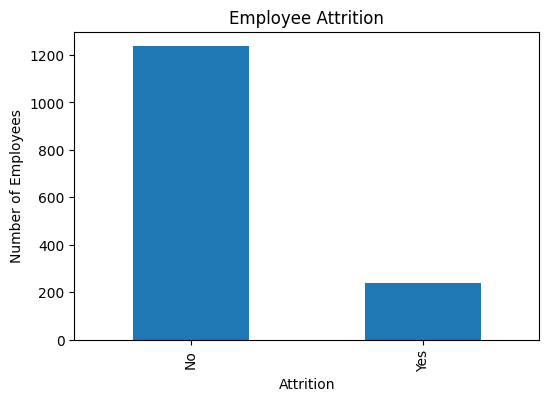

In [16]:
import matplotlib.pyplot as plt

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6,4))
attrition_counts.plot(kind='bar')

plt.title('Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

## Attrition Overview

The organization has an attrition rate of 16.09%.

*   Out of all employees, 83.91% remain with the company while 16.09% have left.
*   This indicates that approximately one in six employees leaves the organization, making employee retention a key area for further analysis.

In [24]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

dept_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.188993,13.811007
Sales,79.418345,20.581655



*   Employee turnover is not evenly distributed across departments. The Sales department experiences the highest attrition rate at 20.58%, suggesting retention challenges that may warrant further investigation. Research & Development demonstrates the strongest retention performance with an attrition rate of 13.81%.




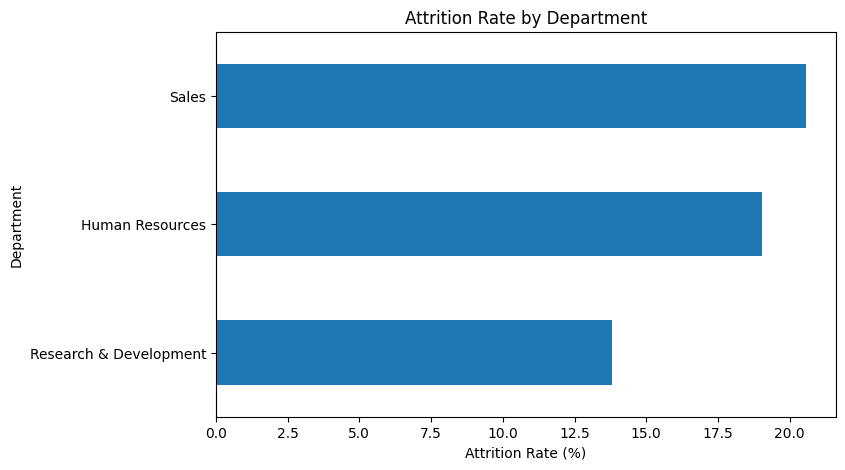

In [25]:
dept_attrition["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.show()

In [26]:
role_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

role_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
JobRole,,
Sales Representative,60.714286,39.285714
Laboratory Technician,76.153846,23.846154
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.181818,6.818182
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


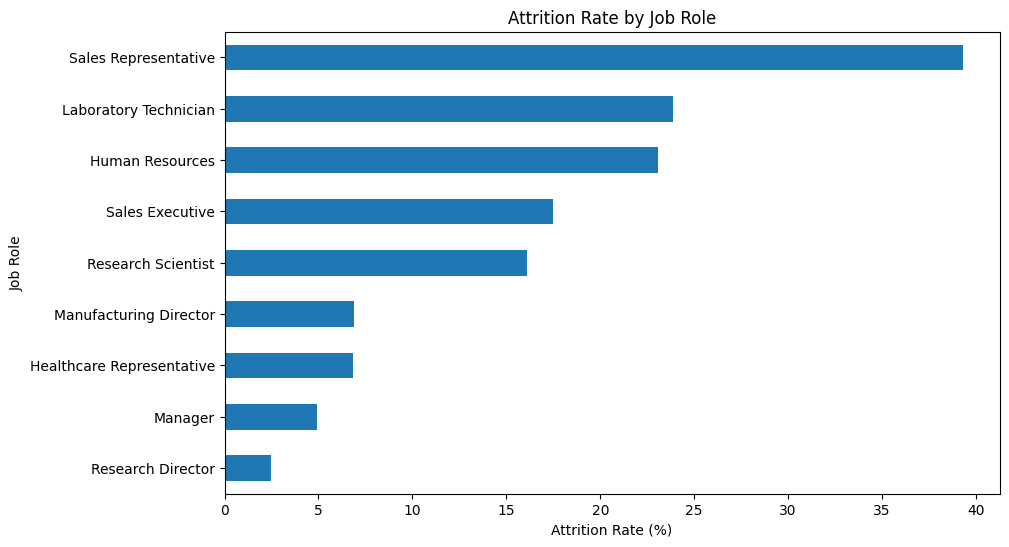

In [27]:
role_attrition["Yes"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

## Job Role Attrition Analysis

Attrition rates vary significantly by job role.

*   Sales Representatives experience the highest attrition rate at 39.29%, indicating a substantial retention challenge within customer-facing positions.
*   Laboratory Technicians (23.85%) and Human Resources professionals (23.08%) also demonstrate elevated turnover.


*   In contrast, leadership positions such as Managers (4.90%) and Research Directors (2.50%) exhibit strong employee retention.

*   These findings suggest that retention initiatives should focus primarily on operational and sales-oriented roles.





In [28]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.593188,10.406812
Yes,69.471154,30.528846


Employees working overtime exhibit an attrition rate of 30.53%, compared with 10.41% for employees who do not work overtime. This suggests a strong relationship between workload and employee turnover, making overtime one of the most significant retention risk factors in the organization.

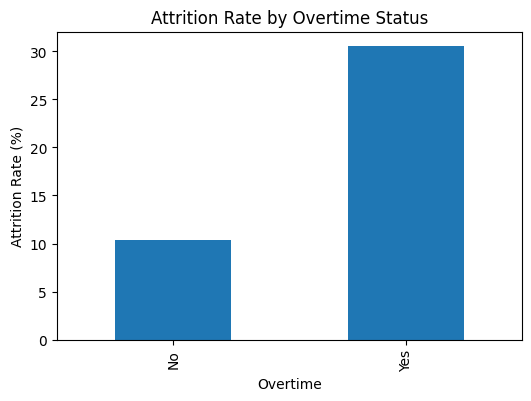

In [29]:
overtime_attrition["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [30]:
salary_attrition = pd.crosstab(
    df["SalarySlab"],
    df["Attrition"],
    normalize="index"
) * 100

salary_attrition

Attrition,No,Yes
SalarySlab,,
10k-15k,86.486486,13.513514
15k+,96.240602,3.759398
5k-10k,88.888889,11.111111
Upto 5k,78.295606,21.704394


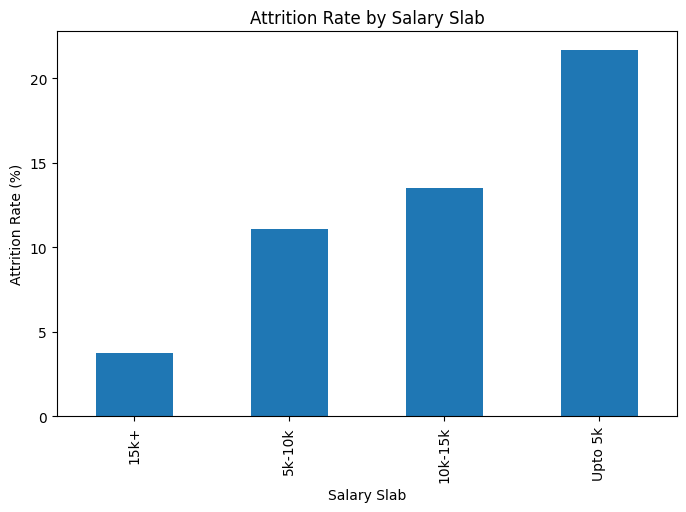

In [31]:
salary_attrition["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Salary Slab")
plt.xlabel("Salary Slab")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [32]:
wlb_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

wlb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.825893,14.174107
4,82.352941,17.647059


In [33]:
tenure_attrition = df.groupby("Attrition")["YearsAtCompany"].mean()

tenure_attrition

,YearsAtCompany
Attrition,
No,7.364078
Yes,5.130802


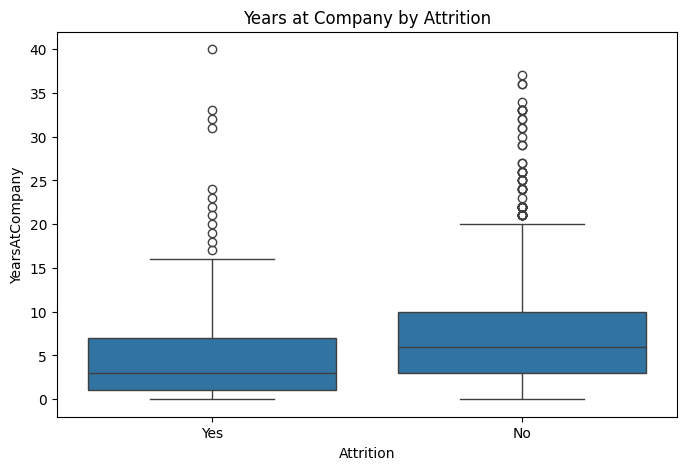

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company by Attrition")
plt.show()

In [35]:
job_sat_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

job_sat_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.241379,22.758621
2,83.571429,16.428571
3,83.521445,16.478555
4,88.695652,11.304348


# 4.Final Conclusion

The analysis identified several factors associated with higher employee attrition.

Key findings include:

- Overall attrition rate is 16.09%.
- Sales Representatives exhibit the highest attrition rate (39.29%).
- Employees working overtime experience nearly three times higher attrition than employees who do not work overtime.
- Employees reporting poor work-life balance demonstrate significantly higher turnover.
- Lower salary groups experience higher attrition compared to higher-paid employees.
- Employees with low job satisfaction are more likely to leave the organization.
- Employees who leave tend to have shorter tenures than those who remain.

The results suggest that workload, employee wellbeing, compensation, and job satisfaction are important factors influencing employee retention.

# Recommendations

Based on the findings, the following actions are recommended:

1. Review overtime policies and workload distribution to reduce employee burnout.
2. Implement retention initiatives for Sales Representatives and other high-turnover roles.
3. Improve work-life balance through flexible working arrangements and employee wellbeing programs.
4. Review compensation strategies for lower-paid employee groups.
5. Conduct employee satisfaction surveys to identify and address workplace concerns.
6. Strengthen onboarding and support programs for early-career employees to improve retention during the first years of employment.

In [36]:
#df.to_csv("HR_Analytics_Cleaned.csv", index=False)

In [37]:
#from google.colab import files

#files.download("HR_Analytics_Cleaned.csv")